# House Price Prediction — Assignment 02

Notebook này xây dựng bài toán **dự đoán giá nhà (`price_million_vnd`)**.

- Phần ML: Linear Regression, Ridge, Random Forest.
- Phần Deep Learning: MLP **tự cài đặt bằng NumPy**, không dùng PyTorch/Keras/TensorFlow.
- Kiến trúc DL mặc định: `Input → 64 → 32 → 16 → 8 → 1`.
- Có preprocessing, đánh giá, hyperparameter experiments, learning curves, residual analysis và lưu model.


In [1]:
# =============================================================
# CELL 1: IMPORTS
# =============================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split, KFold
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

np.random.seed(42)
pd.set_option("display.max_columns", None)


## 1. Load dataset

Đặt `train.csv` cùng thư mục với notebook. Nếu tên file khác, sửa biến `DATA_PATH`.


In [2]:
DATA_PATH = "data\house_buying_dec29th_2025.csv"

df = pd.read_csv(DATA_PATH)

print("Shape:", df.shape)
display(df.head())


Shape: (66912, 11)


,id,detail_url,title,location,timeline_hours,area_m2,bedrooms,bathrooms,floors,frontage,price_million_vnd
0,196958,https://batdongsan.vn/ban-nha-nguyen-son-long-...,Bán nhà Nguyễn Sơn Long Biên- Dân trí Tuyệt vờ...,"Long Biên, Hà Nội",2,50.0,4.0,4.0,6.0,False,12500.0
1,196967,https://batdongsan.vn/ban-nha-hem-xe-hoi-4m-2-...,"BÁN NHÀ HẺM XE HƠI 4M, 2 MẶT TIỀN - 2 TẦNG , N...","Bình Chánh, Hồ Chí Minh",2,98.0,4.0,4.0,3.0,True,5500.0
2,196983,https://batdongsan.vn/o-to-ngu-nha-62m2-5-tang...,Ô TÔ NGỦ NHÀ – 62M² – 5 Tầng/4PN – Gần kdc CIT...,"Gò Vấp, Hồ Chí Minh",2,62.0,4.0,5.0,6.0,False,8740.0
3,196962,https://batdongsan.vn/ban-nha-phuc-loi-ngo-non...,Bán nhà Phúc Lợi - ngõ nông - ô tô vào nhà - t...,"Long Biên, Hà Nội",2,39.0,3.0,4.0,6.0,False,6500.0
4,196972,https://batdongsan.vn/tran-duy-hung-6-tang-tha...,TRẦN DUY HƯNG - 6 TẦNG THANG MÁY - NGÕ THÔNG D...,"Cầu Giấy, Hà Nội",2,45.0,3.0,3.0,7.0,True,16980.0


## 2. Data inspection and understanding

In [3]:
print("=== INFO ===")
df.info()

print("\n=== DESCRIBE ===")
display(df.describe(include="all").T)

print("\n=== MISSING VALUES ===")
missing = df.isnull().sum()
missing_pct = missing / len(df) * 100
missing_df = pd.DataFrame({"Missing": missing, "Percent": missing_pct})
display(missing_df[missing_df["Missing"] > 0].sort_values("Percent", ascending=False))

print("\n=== DUPLICATES ===")
print("Số dòng trùng lặp:", df.duplicated().sum())


=== INFO ===
<class 'pandas.DataFrame'>
RangeIndex: 66912 entries, 0 to 66911
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 66912 non-null  int64  
 1   detail_url         66905 non-null  str    
 2   title              66912 non-null  str    
 3   location           66912 non-null  str    
 4   timeline_hours     66912 non-null  int64  
 5   area_m2            50344 non-null  float64
 6   bedrooms           55273 non-null  float64
 7   bathrooms          51548 non-null  float64
 8   floors             52278 non-null  float64
 9   frontage           66912 non-null  bool   
 10  price_million_vnd  64809 non-null  float64
dtypes: bool(1), float64(5), int64(2), str(3)
memory usage: 18.9 MB

=== DESCRIBE ===


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
id,66912.0,NaN,NaN,NaN,141092.732768,32545.265005,80084.0,116152.75,142310.0,168691.5,197061.0
detail_url,66905,66905,https://batdongsan.vn/ban-nha-nguyen-son-long-...,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
title,66912,66899,✨ TINH HOA TRẦN VĂN QUANG - HXH – 4 TẦNG BTCT...,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
location,66912,280,"Gò Vấp, Hồ Chí Minh",3441,NaN,NaN,NaN,NaN,NaN,NaN,NaN
timeline_hours,66912.0,NaN,NaN,NaN,8749.222666,6863.201079,2.0,3600.0,7200.0,8760.0,26280.0
area_m2,50344.0,NaN,NaN,NaN,1377.9767,276334.663515,1.0,42.0,60.0,92.0,62000000.0
bedrooms,55273.0,NaN,NaN,NaN,4.429649,4.500243,1.0,3.0,4.0,5.0,127.0
bathrooms,51548.0,NaN,NaN,NaN,4.296617,4.618477,1.0,2.0,3.0,5.0,127.0
floors,52278.0,NaN,NaN,NaN,14775.954379,3377398.558508,0.0,3.0,4.0,6.0,772221339.0
frontage,66912,2,False,52086,NaN,NaN,NaN,NaN,NaN,NaN,NaN



=== MISSING VALUES ===


,Missing,Percent
area_m2,16568,24.760880
bathrooms,15364,22.961502
floors,14634,21.870516
bedrooms,11639,17.394488
price_million_vnd,2103,3.142934
detail_url,7,0.010462



=== DUPLICATES ===
Số dòng trùng lặp: 0


## 3. Data cleaning

- Xóa duplicated records.
- `price_million_vnd <= 0` được xem là invalid và loại bỏ.
- `area_m2 <= 0` → missing.
- `bedrooms`, `bathrooms` ngoài khoảng hợp lý → missing.
- `floors` và `timeline_hours` được kiểm tra nếu tồn tại.
- Missing features được xử lý bằng imputation trong pipeline.
- Outlier được **báo cáo nhưng không tự động xóa**, nhằm tránh mất dữ liệu hợp lệ.


In [4]:
df = df.drop_duplicates().reset_index(drop=True)

target = "price_million_vnd"

if target not in df.columns:
    raise ValueError(f"Không tìm thấy target '{target}'. Columns: {df.columns.tolist()}")

df = df[df[target].notna() & (df[target] > 0)].copy()

if "area_m2" in df.columns:
    df.loc[df["area_m2"] <= 0, "area_m2"] = np.nan

if "bedrooms" in df.columns:
    df.loc[(df["bedrooms"] <= 0) | (df["bedrooms"] > 20), "bedrooms"] = np.nan

if "bathrooms" in df.columns:
    df.loc[(df["bathrooms"] <= 0) | (df["bathrooms"] > 20), "bathrooms"] = np.nan

if "floors" in df.columns:
    df.loc[(df["floors"] < 0) | (df["floors"] > 100), "floors"] = np.nan

if "timeline_hours" in df.columns:
    df.loc[df["timeline_hours"] <= 0, "timeline_hours"] = np.nan

print("Shape sau cleaning:", df.shape)


Shape sau cleaning: (64447, 11)


## 4. Outlier analysis bằng IQR

In [5]:
num_cols = [
    c for c in ["timeline_hours", "area_m2", "bedrooms", "bathrooms", "floors"]
    if c in df.columns
]

outlier_report = []

for c in num_cols + [target]:
    q1 = df[c].quantile(0.25)
    q3 = df[c].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    n_out = ((df[c] < lower) | (df[c] > upper)).sum()

    outlier_report.append({
        "column": c,
        "Q1": q1,
        "Q3": q3,
        "IQR": iqr,
        "lower": lower,
        "upper": upper,
        "n_outliers": n_out,
        "pct": 100 * n_out / len(df)
    })

outlier_df = pd.DataFrame(outlier_report)
display(outlier_df)


,column,Q1,Q3,IQR,lower,upper,n_outliers,pct
0,timeline_hours,3600.0,8760.0,5160.0,-4140.0,16500.0,14358,22.278772
1,area_m2,42.0,92.0,50.0,-33.0,167.0,4254,6.600773
2,bedrooms,3.0,4.0,1.0,1.5,5.5,10174,15.786615
3,bathrooms,2.0,5.0,3.0,-2.5,9.5,2053,3.185563
4,floors,3.0,6.0,3.0,-1.5,10.5,292,0.453085
5,price_million_vnd,4650.0,12800.0,8150.0,-7575.0,25025.0,5837,9.057055


## 5. Visualization

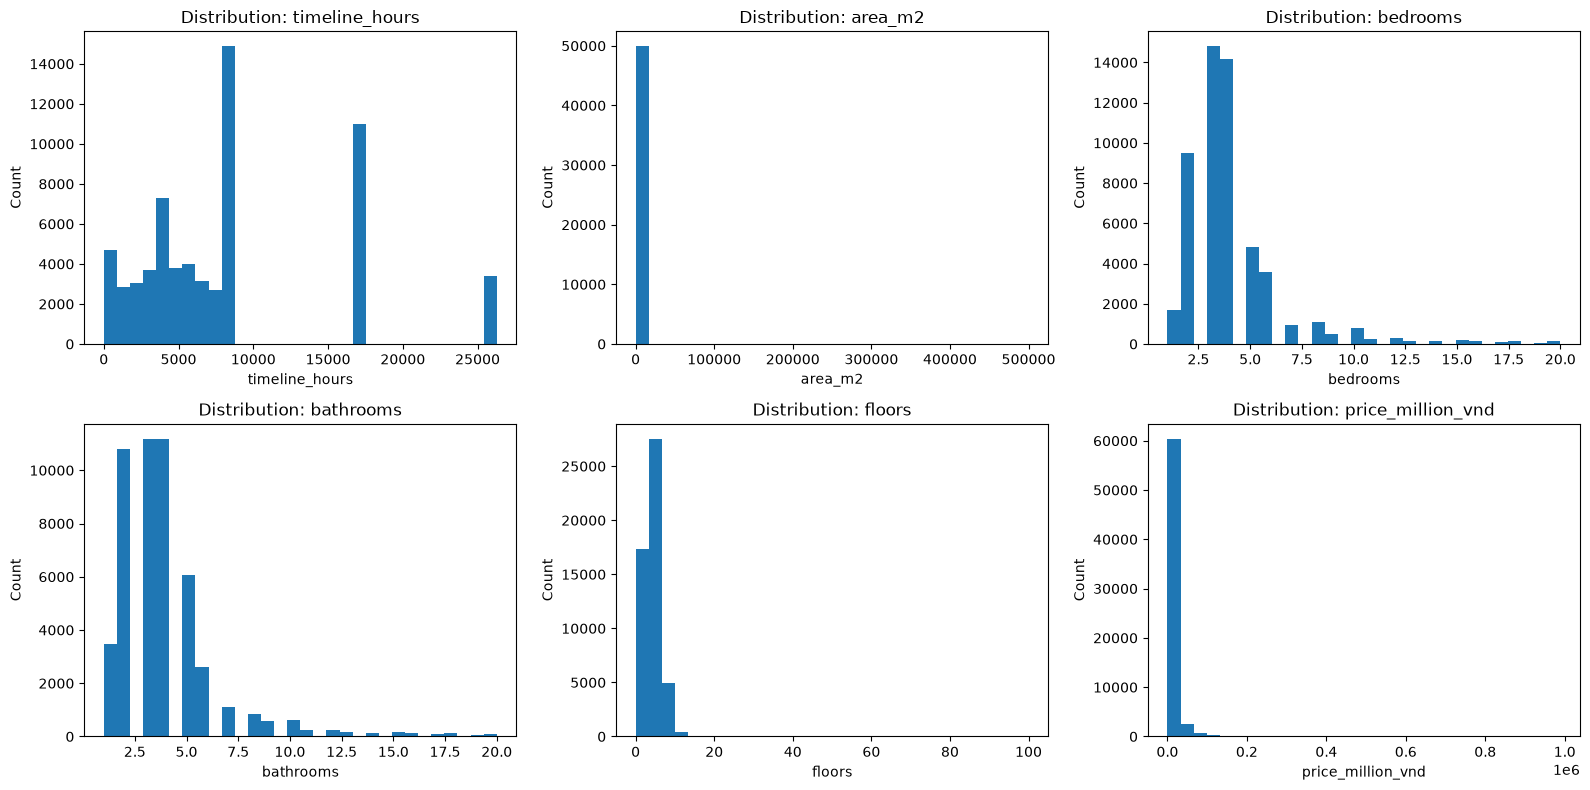

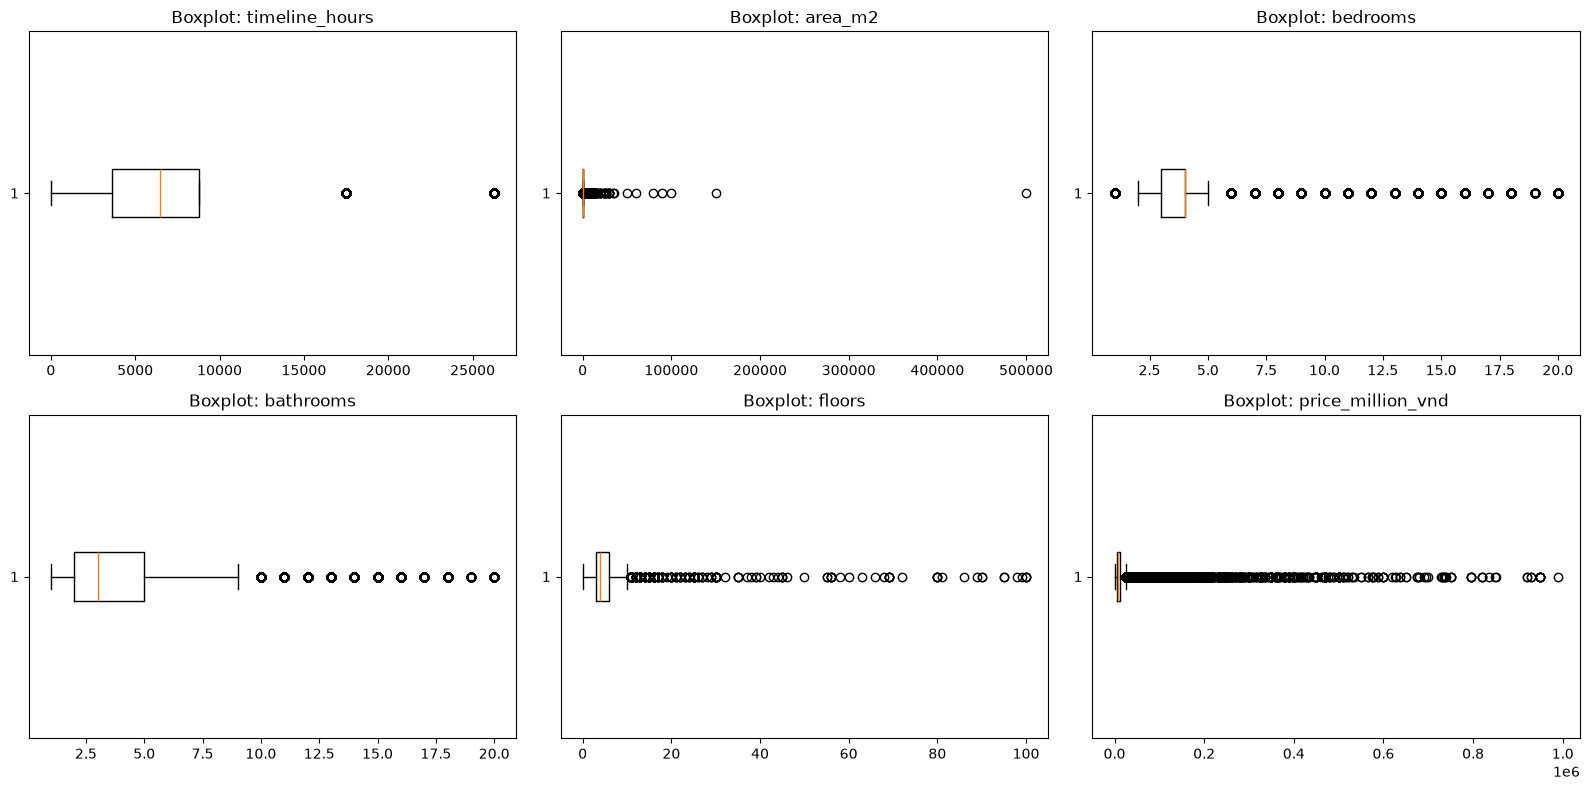

In [6]:
cols_to_plot = [c for c in num_cols + [target] if c in df.columns]

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()

for ax, c in zip(axes, cols_to_plot):
    ax.hist(df[c].dropna(), bins=30)
    ax.set_title(f"Distribution: {c}")
    ax.set_xlabel(c)
    ax.set_ylabel("Count")

for ax in axes[len(cols_to_plot):]:
    ax.axis("off")

plt.tight_layout()
plt.show()

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()

for ax, c in zip(axes, cols_to_plot):
    ax.boxplot(df[c].dropna(), vert=False)
    ax.set_title(f"Boxplot: {c}")

for ax in axes[len(cols_to_plot):]:
    ax.axis("off")

plt.tight_layout()
plt.show()


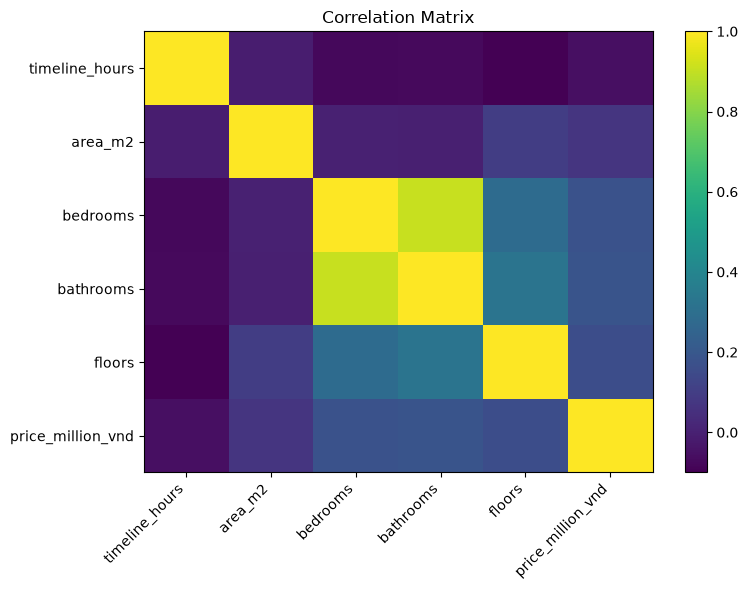

In [7]:
corr_cols = [c for c in num_cols + [target] if c in df.columns]
corr = df[corr_cols].corr()

plt.figure(figsize=(8, 6))
plt.imshow(corr, aspect="auto")
plt.colorbar()
plt.xticks(range(len(corr.columns)), corr.columns, rotation=45, ha="right")
plt.yticks(range(len(corr.columns)), corr.columns)
plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()


## 6. Location analysis

Số location unique: 272


,count
location,
"Gò Vấp, Hồ Chí Minh",3261
"Tân Phú, Hồ Chí Minh",3150
"Đống Đa, Hà Nội",3127
"Bình Tân, Hồ Chí Minh",3052
"Long Biên, Hà Nội",3047
"Quận 12, Hồ Chí Minh",2737
"Cầu Giấy, Hà Nội",2605
"Tân Bình, Hồ Chí Minh",2575
"Thanh Xuân, Hà Nội",2573


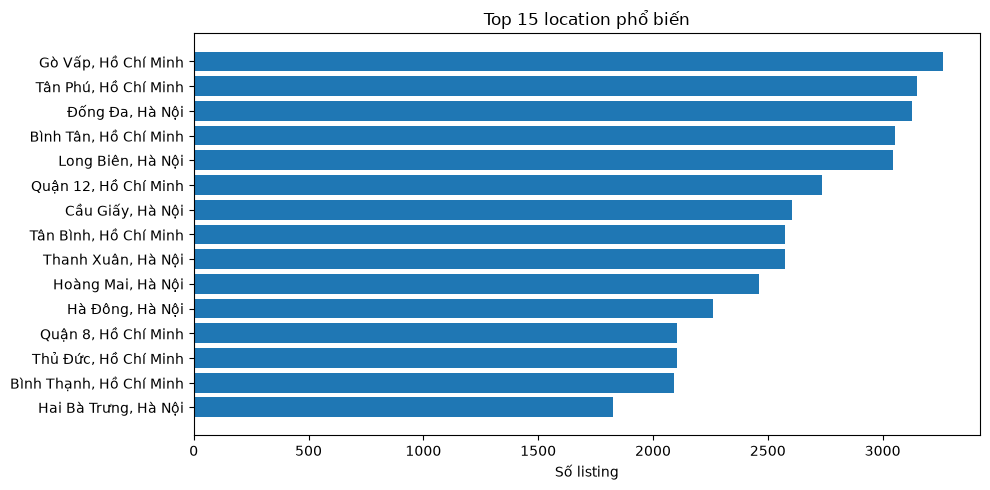

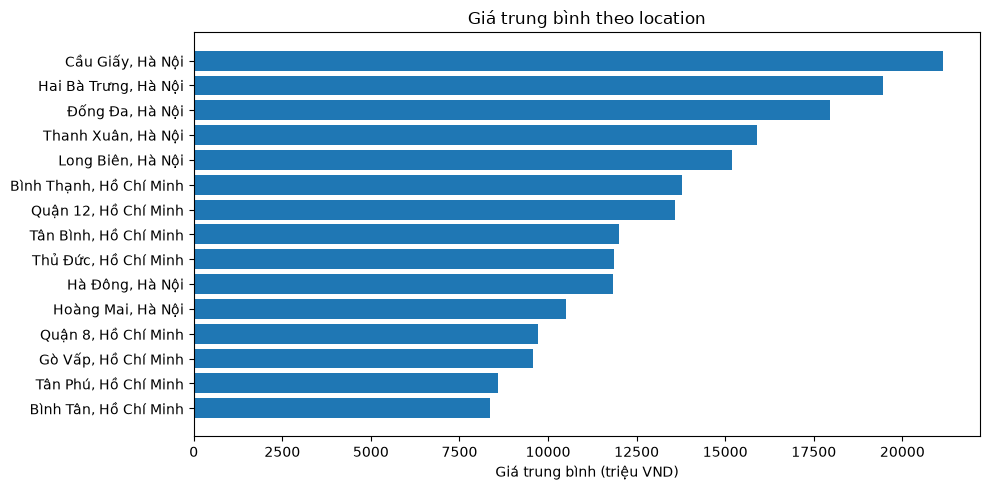

In [8]:
if "location" in df.columns:
    print("Số location unique:", df["location"].nunique())
    top_loc = df["location"].value_counts().head(15)
    display(top_loc.to_frame("count"))

    plt.figure(figsize=(10, 5))
    plt.barh(top_loc.index.astype(str)[::-1], top_loc.values[::-1])
    plt.title("Top 15 location phổ biến")
    plt.xlabel("Số listing")
    plt.tight_layout()
    plt.show()

    mean_price = (
        df[df["location"].isin(top_loc.index)]
        .groupby("location")[target]
        .mean()
        .sort_values(ascending=False)
    )

    plt.figure(figsize=(10, 5))
    plt.barh(mean_price.index.astype(str)[::-1], mean_price.values[::-1])
    plt.title("Giá trung bình theo location")
    plt.xlabel("Giá trung bình (triệu VND)")
    plt.tight_layout()
    plt.show()


## 7. Feature engineering và preprocessing

In [9]:
if "frontage" in df.columns:
    def encode_frontage(x):
        s = str(x).strip().lower()
        return 1 if s in ("true", "1", "yes", "y", "co", "có") else 0

    df["frontage"] = df["frontage"].apply(encode_frontage)

numeric_features = [
    c for c in [
        "timeline_hours", "area_m2", "bedrooms",
        "bathrooms", "floors", "frontage"
    ] if c in df.columns
]

categorical_features = ["location"] if "location" in df.columns else []

print("Numeric:", numeric_features)
print("Categorical:", categorical_features)

X = df[numeric_features + categorical_features].copy()
y = df[target].astype(np.float32).values

print("X shape:", X.shape)
print("y shape:", y.shape)


Numeric: ['timeline_hours', 'area_m2', 'bedrooms', 'bathrooms', 'floors', 'frontage']
Categorical: ['location']
X shape: (64447, 7)
y shape: (64447,)


## 8. Train / validation / test split

In [10]:
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full, test_size=0.20, random_state=42
)

print("Train:", X_train.shape)
print("Val:", X_val.shape)
print("Test:", X_test.shape)


Train: (41245, 7)
Val: (10312, 7)
Test: (12890, 7)


In [11]:
numeric_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

transformers = [("num", numeric_pipe, numeric_features)]

if categorical_features:
    transformers.append(("cat", categorical_pipe, categorical_features))

preprocessor = ColumnTransformer(transformers)

X_train_proc = preprocessor.fit_transform(X_train).astype(np.float32)
X_val_proc = preprocessor.transform(X_val).astype(np.float32)
X_test_proc = preprocessor.transform(X_test).astype(np.float32)

print("After preprocessing:", X_train_proc.shape)


After preprocessing: (41245, 251)


## 9. ML baselines

In [12]:
def evaluate(y_true, y_pred, name):
    mse = mean_squared_error(y_true, y_pred)
    return {
        "Model": name,
        "MSE": mse,
        "RMSE": np.sqrt(mse),
        "MAE": mean_absolute_error(y_true, y_pred),
        "R2": r2_score(y_true, y_pred)
    }

ml_models = {
    "LinearRegression": LinearRegression(),
    "Ridge": Ridge(alpha=1.0),
    "RandomForest": RandomForestRegressor(
        n_estimators=200,
        random_state=42,
        n_jobs=-1
    )
}

ml_results = []
ml_predictions = {}

for name, model in ml_models.items():
    model.fit(X_train_proc, y_train)

    pred_val = model.predict(X_val_proc)
    pred_test = model.predict(X_test_proc)

    ml_predictions[name] = {
        "val": pred_val,
        "test": pred_test
    }

    ml_results.append(evaluate(y_val, pred_val, name + " (val)"))
    ml_results.append(evaluate(y_test, pred_test, name + " (test)"))

ml_df = pd.DataFrame(ml_results)
display(ml_df)


,Model,MSE,RMSE,MAE,R2
0,LinearRegression (val),1.013785e+09,31839.984925,10091.308594,-0.059770
1,LinearRegression (test),1.465848e+09,38286.388600,11141.777344,-0.001427
2,Ridge (val),8.959533e+08,29932.478681,9677.428711,0.063406
3,Ridge (test),1.351731e+09,36765.890279,10740.538086,0.076535
4,RandomForest (val),8.214453e+08,28660.866365,6729.682276,0.141294
5,RandomForest (test),1.094300e+09,33080.200732,7349.411941,0.252405


# 10. Deep Learning from scratch bằng NumPy

Kiến trúc:

`Input → 64 → 32 → 16 → 8 → 1`

Hidden layers dùng ReLU, output dùng linear activation. Loss là MSE.
Optimizer hỗ trợ SGD, Momentum và Adam.


In [13]:
def relu(x):
    return np.maximum(0, x)

def relu_derivative(x):
    return (x > 0).astype(x.dtype)

def mse_loss(y_true, y_pred):
    return np.mean((y_true - y_pred) ** 2)

def mse_grad(y_true, y_pred):
    n = y_true.shape[0]
    return (2.0 / n) * (y_pred - y_true)

def he_init(fan_in, fan_out, rng):
    return rng.standard_normal((fan_in, fan_out)) * np.sqrt(2.0 / fan_in)


In [14]:
class MLPRegressor:
    """MLP regression tự cài đặt bằng NumPy."""

    def __init__(
        self,
        input_dim,
        hidden_dims=(64, 32, 16, 8),
        init="he",
        lr=0.01,
        optimizer="adam",
        momentum=0.9,
        beta1=0.9,
        beta2=0.999,
        eps=1e-8,
        seed=42
    ):
        self.rng = np.random.default_rng(seed)
        self.input_dim = input_dim
        self.hidden_dims = tuple(hidden_dims)
        self.lr = lr
        self.optimizer = optimizer.lower()
        self.momentum = momentum
        self.beta1 = beta1
        self.beta2 = beta2
        self.eps = eps

        sizes = [input_dim] + list(hidden_dims) + [1]
        self.sizes = sizes
        self.L = len(sizes) - 1

        self.W = []
        self.b = []

        for i in range(self.L):
            if init == "he":
                W = he_init(sizes[i], sizes[i + 1], self.rng)
            else:
                W = self.rng.standard_normal(
                    (sizes[i], sizes[i + 1])
                ) * np.sqrt(1.0 / sizes[i])

            self.W.append(W)
            self.b.append(np.zeros((1, sizes[i + 1])))

        self._init_optimizer_state()

    def _init_optimizer_state(self):
        if self.optimizer == "momentum":
            self.vW = [np.zeros_like(w) for w in self.W]
            self.vb = [np.zeros_like(b) for b in self.b]

        elif self.optimizer == "adam":
            self.mW = [np.zeros_like(w) for w in self.W]
            self.mb = [np.zeros_like(b) for b in self.b]
            self.vW = [np.zeros_like(w) for w in self.W]
            self.vb = [np.zeros_like(b) for b in self.b]
            self.t = 0

    def forward(self, X):
        cache = {"A": [X], "Z": []}
        A = X

        for i in range(self.L):
            Z = A @ self.W[i] + self.b[i]
            cache["Z"].append(Z)

            if i < self.L - 1:
                A = relu(Z)
            else:
                A = Z

            cache["A"].append(A)

        return A, cache

    def backward(self, y, cache):
        y = np.asarray(y).reshape(-1, 1)
        y_pred = cache["A"][-1]
        dA = mse_grad(y, y_pred)

        dW = [None] * self.L
        db = [None] * self.L

        for i in reversed(range(self.L)):
            if i == self.L - 1:
                dZ = dA
            else:
                dZ = dA * relu_derivative(cache["Z"][i])

            dW[i] = cache["A"][i].T @ dZ
            db[i] = np.sum(dZ, axis=0, keepdims=True)

            if i > 0:
                dA = dZ @ self.W[i].T

        return dW, db

    def update(self, dW, db):
        if self.optimizer == "sgd":
            for i in range(self.L):
                self.W[i] -= self.lr * dW[i]
                self.b[i] -= self.lr * db[i]

        elif self.optimizer == "momentum":
            for i in range(self.L):
                self.vW[i] = self.momentum * self.vW[i] - self.lr * dW[i]
                self.vb[i] = self.momentum * self.vb[i] - self.lr * db[i]
                self.W[i] += self.vW[i]
                self.b[i] += self.vb[i]

        elif self.optimizer == "adam":
            self.t += 1

            for i in range(self.L):
                self.mW[i] = self.beta1 * self.mW[i] + (1 - self.beta1) * dW[i]
                self.mb[i] = self.beta1 * self.mb[i] + (1 - self.beta1) * db[i]

                self.vW[i] = self.beta2 * self.vW[i] + (1 - self.beta2) * (dW[i] ** 2)
                self.vb[i] = self.beta2 * self.vb[i] + (1 - self.beta2) * (db[i] ** 2)

                mW_hat = self.mW[i] / (1 - self.beta1 ** self.t)
                mb_hat = self.mb[i] / (1 - self.beta1 ** self.t)
                vW_hat = self.vW[i] / (1 - self.beta2 ** self.t)
                vb_hat = self.vb[i] / (1 - self.beta2 ** self.t)

                self.W[i] -= self.lr * mW_hat / (np.sqrt(vW_hat) + self.eps)
                self.b[i] -= self.lr * mb_hat / (np.sqrt(vb_hat) + self.eps)

    def predict(self, X):
        A = X

        for i in range(self.L):
            Z = A @ self.W[i] + self.b[i]
            A = relu(Z) if i < self.L - 1 else Z

        return A.flatten()


## 11. Scaling dữ liệu cho Deep Learning

In [15]:
scaler_X = StandardScaler()

X_train_nn = scaler_X.fit_transform(X_train_proc).astype(np.float32)
X_val_nn = scaler_X.transform(X_val_proc).astype(np.float32)
X_test_nn = scaler_X.transform(X_test_proc).astype(np.float32)

y_mean = y_train.mean()
y_std = y_train.std() + 1e-8

y_train_nn = ((y_train - y_mean) / y_std).astype(np.float32)
y_val_nn = ((y_val - y_mean) / y_std).astype(np.float32)
y_test_nn = ((y_test - y_mean) / y_std).astype(np.float32)

print("X_train_nn:", X_train_nn.shape)
print("y_train_nn mean/std:", y_train_nn.mean(), y_train_nn.std())


X_train_nn: (41245, 251)
y_train_nn mean/std: 7.3990974e-10 1.0


In [16]:
def train_mlp(
    model,
    X_train,
    y_train,
    X_val,
    y_val,
    epochs=200,
    batch_size=32,
    verbose=True
):
    n = X_train.shape[0]
    history = {"train_loss": [], "val_loss": []}

    for epoch in range(epochs):
        idx = np.random.permutation(n)
        X_sh = X_train[idx]
        y_sh = y_train[idx]

        for i in range(0, n, batch_size):
            xb = X_sh[i:i + batch_size]
            yb = y_sh[i:i + batch_size]

            y_pred, cache = model.forward(xb)
            dW, db = model.backward(yb, cache)
            model.update(dW, db)

        pred_tr = model.predict(X_train)
        pred_v = model.predict(X_val)

        tr_loss = mse_loss(y_train, pred_tr)
        v_loss = mse_loss(y_val, pred_v)

        history["train_loss"].append(tr_loss)
        history["val_loss"].append(v_loss)

        if verbose and (
            epoch % max(1, epochs // 10) == 0
            or epoch == epochs - 1
        ):
            print(
                f"Epoch {epoch + 1:4d} | "
                f"train MSE = {tr_loss:.5f} | "
                f"val MSE = {v_loss:.5f}"
            )

    return history

def eval_dl(model, X):
    y_pred_norm = model.predict(X)
    return y_pred_norm * y_std + y_mean


## 12. Baseline Deep Learning

In [17]:
np.random.seed(42)

model_base = MLPRegressor(
    input_dim=X_train_nn.shape[1],
    hidden_dims=(64, 32, 16, 8),
    init="he",
    lr=0.01,
    optimizer="adam",
    seed=42
)

hist_base = train_mlp(
    model_base,
    X_train_nn,
    y_train_nn,
    X_val_nn,
    y_val_nn,
    epochs=200,
    batch_size=32,
    verbose=True
)

y_pred_base = eval_dl(model_base, X_test_nn)
display(pd.DataFrame([evaluate(y_test, y_pred_base, "DL baseline (test)")]))


Epoch    1 | train MSE = 0.92278 | val MSE = 0.73678
Epoch   21 | train MSE = 0.60630 | val MSE = 0.58651
Epoch   41 | train MSE = 0.61826 | val MSE = 0.56886
Epoch   61 | train MSE = 0.60428 | val MSE = 0.55960
Epoch   81 | train MSE = 0.56061 | val MSE = 0.57448
Epoch  101 | train MSE = 0.54466 | val MSE = 0.57701
Epoch  121 | train MSE = 0.53934 | val MSE = 0.58078
Epoch  141 | train MSE = 0.59445 | val MSE = 0.54319
Epoch  161 | train MSE = 0.60487 | val MSE = 0.61912
Epoch  181 | train MSE = 0.54151 | val MSE = 0.56164
Epoch  200 | train MSE = 0.55019 | val MSE = 0.57375


,Model,MSE,RMSE,MAE,R2
0,DL baseline (test),1.109664e+09,33311.616325,8776.27734,0.241908


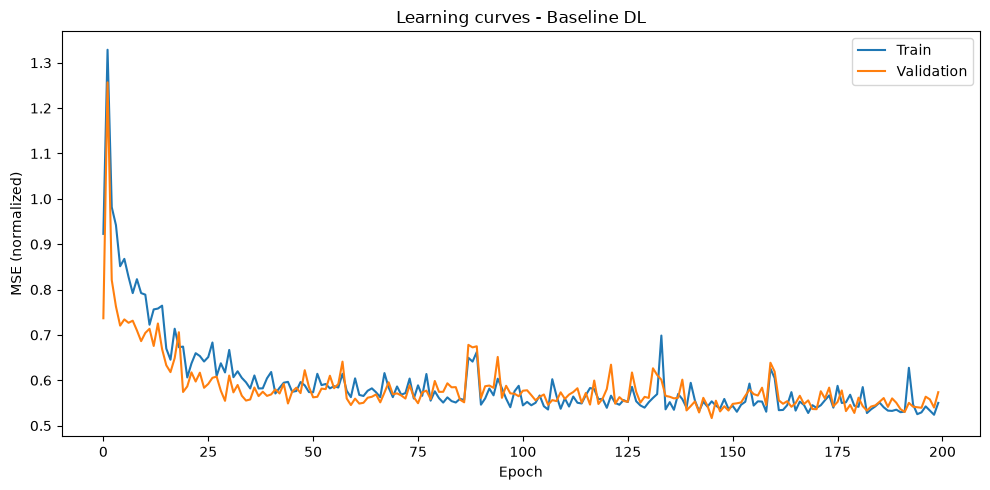

In [18]:
plt.figure(figsize=(10, 5))
plt.plot(hist_base["train_loss"], label="Train")
plt.plot(hist_base["val_loss"], label="Validation")
plt.xlabel("Epoch")
plt.ylabel("MSE (normalized)")
plt.title("Learning curves - Baseline DL")
plt.legend()
plt.tight_layout()
plt.show()


## 13. Hyperparameter experiments

So sánh:
- độ sâu/width
- learning rate
- optimizer
- batch size


In [20]:
# =============================================================
# CELL: HYPERPARAMETER EXPERIMENTS (TỐI ƯU TỐC ĐỘ)
# =============================================================
import time
import numpy as np
import pandas as pd
from IPython.display import display

# -------------------------------------------------------------
# 1. CẤU HÌNH EXPERIMENTS (rút gọn còn 6, đủ để so sánh)
# -------------------------------------------------------------
experiments = [
    {"name": "base",      "hidden": (64, 32, 16, 8),   "lr": 0.01,  "opt": "adam",     "bs": 64},
    {"name": "deep",      "hidden": (128, 64, 32, 16), "lr": 0.01,  "opt": "adam",     "bs": 64},
    {"name": "lr_small",  "hidden": (64, 32, 16, 8),   "lr": 0.001, "opt": "adam",     "bs": 64},
    {"name": "sgd",       "hidden": (64, 32, 16, 8),   "lr": 0.01,  "opt": "sgd",      "bs": 64},
    {"name": "momentum",  "hidden": (64, 32, 16, 8),   "lr": 0.01,  "opt": "momentum", "bs": 64},
    {"name": "batch_16",  "hidden": (64, 32, 16, 8),   "lr": 0.01,  "opt": "adam",     "bs": 16},
]

EPOCHS = 60       # giảm từ 200 -> 60
EVAL_EVERY = 5    # chỉ eval validation mỗi 5 epoch

# -------------------------------------------------------------
# 2. TRAINING LOOP TỐI ƯU
# -------------------------------------------------------------
def train_mlp_fast(model, X_train, y_train, X_val, y_val,
                   epochs=60, batch_size=64,
                   eval_every=5, verbose=True):
    """
    Tối ưu tốc độ:
    - Không forward toàn bộ train mỗi epoch.
    - Train loss = trung bình loss các batch trong epoch.
    - Val loss chỉ tính mỗi `eval_every` epochs.
    """
    n = X_train.shape[0]
    y_train_col = y_train.reshape(-1, 1)
    y_val_col = y_val.reshape(-1, 1)

    history = {"train_loss": [], "val_loss": []}

    for epoch in range(epochs):
        idx = np.random.permutation(n)
        X_sh = X_train[idx]
        y_sh = y_train_col[idx]

        epoch_loss = 0.0
        n_batches = 0

        for i in range(0, n, batch_size):
            xb = X_sh[i:i + batch_size]
            yb = y_sh[i:i + batch_size]

            y_pred, cache = model.forward(xb)
            epoch_loss += mse_loss(yb, y_pred)
            n_batches += 1

            dW, db = model.backward(yb, cache)
            model.update(dW, db)

        train_loss = epoch_loss / max(n_batches, 1)
        history["train_loss"].append(train_loss)

        # Chỉ eval validation định kỳ
        if (epoch + 1) % eval_every == 0 or epoch == epochs - 1:
            y_pred_v = model.forward(X_val)[0]
            v_loss = mse_loss(y_val_col, y_pred_v)
            history["val_loss"].append(v_loss)
            if verbose:
                print(f"  Epoch {epoch+1:3d}/{epochs} | "
                      f"train={train_loss:.5f} | val={v_loss:.5f}")
        else:
            history["val_loss"].append(np.nan)

    return history

# -------------------------------------------------------------
# 3. CHẠY TẤT CẢ EXPERIMENTS
# -------------------------------------------------------------
dl_results = []
dl_histories = {}
dl_models = {}

total_start = time.time()

for k, exp in enumerate(experiments, 1):
    print(f"\n[{k}/{len(experiments)}] Running: {exp['name']}")
    t0 = time.time()

    np.random.seed(42)
    model = MLPRegressor(
        input_dim=X_train_nn.shape[1],
        hidden_dims=exp["hidden"],
        init="he",
        lr=exp["lr"],
        optimizer=exp["opt"],
        seed=42
    )

    hist = train_mlp_fast(
        model,
        X_train_nn, y_train_nn,
        X_val_nn,   y_val_nn,
        epochs=EPOCHS,
        batch_size=exp["bs"],
        eval_every=EVAL_EVERY,
        verbose=True
    )

    dl_histories[exp["name"]] = hist
    dl_models[exp["name"]] = model

    # Eval 1 lần duy nhất cho val + test
    pred_val  = eval_dl(model, X_val_nn)
    pred_test = eval_dl(model, X_test_nn)

    n_params = sum(w.size for w in model.W) + sum(b.size for b in model.b)

    dl_results.append({
        **evaluate(y_val, pred_val, exp["name"] + " (val)"),
        "params": n_params,
        "time_s": round(time.time() - t0, 2)
    })
    dl_results.append({
        **evaluate(y_test, pred_test, exp["name"] + " (test)"),
        "params": n_params,
        "time_s": round(time.time() - t0, 2)
    })

    print(f"  -> done in {time.time() - t0:.1f}s")

print(f"\nTOTAL TIME: {time.time() - total_start:.1f}s")

# -------------------------------------------------------------
# 4. TỔNG HỢP KẾT QUẢ
# -------------------------------------------------------------
dl_df = pd.DataFrame(dl_results)

dl_df_test = dl_df[dl_df["Model"].str.endswith("(test)")].copy()
dl_df_test["Model"] = dl_df_test["Model"].str.replace(" (test)", "", regex=False)

print("\n=== TEST RESULTS (sorted by RMSE) ===")
display(dl_df_test.sort_values("RMSE").reset_index(drop=True))


[1/6] Running: base
  Epoch   5/60 | train=0.93682 | val=0.72352
  Epoch  10/60 | train=0.87113 | val=0.67292
  Epoch  15/60 | train=0.81398 | val=0.62864
  Epoch  20/60 | train=0.77259 | val=0.62880
  Epoch  25/60 | train=0.77112 | val=0.62484
  Epoch  30/60 | train=0.69747 | val=0.58647
  Epoch  35/60 | train=0.69758 | val=0.59845
  Epoch  40/60 | train=0.67447 | val=0.57905
  Epoch  45/60 | train=0.66252 | val=0.55493
  Epoch  50/60 | train=0.65557 | val=0.73285
  Epoch  55/60 | train=0.66853 | val=0.58045
  Epoch  60/60 | train=0.65638 | val=0.57195
  -> done in 132.6s

[2/6] Running: deep
  Epoch   5/60 | train=0.90256 | val=0.72838
  Epoch  10/60 | train=0.85334 | val=0.66495
  Epoch  15/60 | train=0.82256 | val=0.71717
  Epoch  20/60 | train=0.72974 | val=0.60619
  Epoch  25/60 | train=0.68786 | val=0.62757
  Epoch  30/60 | train=0.79181 | val=0.57963
  Epoch  35/60 | train=0.63719 | val=0.59586
  Epoch  40/60 | train=0.65059 | val=0.59440
  Epoch  45/60 | train=0.61518 | val=0

,Model,MSE,RMSE,MAE,R2,params,time_s
0,deep,1.065931e+09,32648.594018,8812.401680,0.271786,43137,258.19
1,lr_small,1.095117e+09,33092.558503,8194.972123,0.251846,18881,104.00
2,batch_16,1.103275e+09,33215.580964,9080.948989,0.246273,18881,265.12
3,base,1.121027e+09,33481.737133,9516.155026,0.234146,18881,132.55
4,sgd,1.202015e+09,34670.084015,9699.930913,0.178817,18881,95.43
5,momentum,1.467683e+09,38310.353278,11499.187487,-0.002681,18881,207.65


## 14. So sánh learning curves

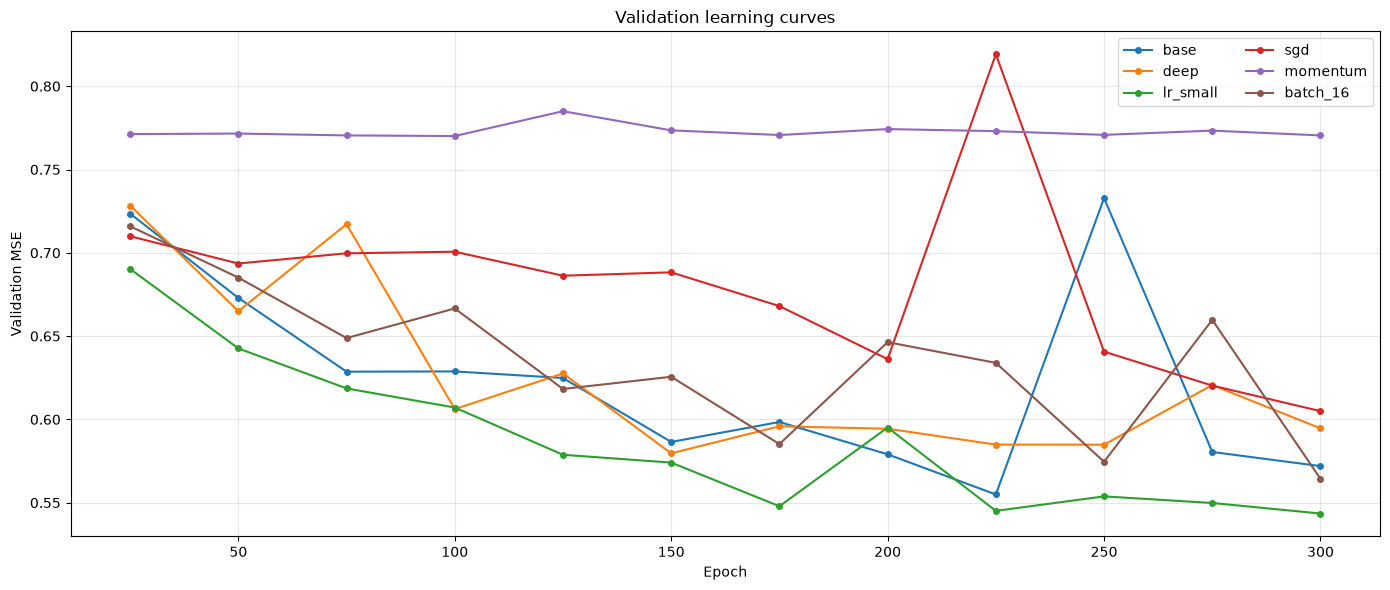

In [32]:
plt.figure(figsize=(14, 6))

for name, history in dl_histories.items():
    # Nếu history có 'val_epoch' -> dùng nó
    if "val_epoch" in history and len(history["val_epoch"]) > 0:
        plt.plot(history["val_epoch"], history["val_loss"],
                 marker="o", markersize=4, label=name)
    else:
        # Fallback: bỏ NaN
        import pandas as pd
        s = pd.Series(history["val_loss"]).dropna()
        x = (s.index + 1) * 5   # 5 = eval_every
        plt.plot(x, s.values, marker="o", markersize=4, label=name)

plt.xlabel("Epoch")
plt.ylabel("Validation MSE")
plt.title("Validation learning curves")
plt.legend(ncol=2)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 15. Chọn best Deep Learning model

In [22]:
best_row = dl_df_test.sort_values("RMSE").iloc[0]
best_name = best_row["Model"]
best_model = dl_models[best_name]

print("Best DL config theo RMSE:")
display(best_row.to_frame().T)


Best DL config theo RMSE:


,Model,MSE,RMSE,MAE,R2,params,time_s
3,deep,1065930691.378839,32648.594018,8812.40168,0.271786,43137,258.19


## 16. Final comparison ML vs DL

In [23]:
ml_test = ml_df[ml_df["Model"].str.endswith("(test)")].copy()
ml_test["Model"] = ml_test["Model"].str.replace(" (test)", "", regex=False)

ml_best = ml_test.sort_values("RMSE").iloc[0].copy()
dl_best = best_row.copy()

comparison = pd.DataFrame([
    {
        "Type": "ML",
        "Model": ml_best["Model"],
        "RMSE": ml_best["RMSE"],
        "MAE": ml_best["MAE"],
        "R2": ml_best["R2"]
    },
    {
        "Type": "DL",
        "Model": dl_best["Model"],
        "RMSE": dl_best["RMSE"],
        "MAE": dl_best["MAE"],
        "R2": dl_best["R2"]
    }
])

display(comparison.sort_values("RMSE"))


,Type,Model,RMSE,MAE,R2
1,DL,deep,32648.594018,8812.401680,0.271786
0,ML,RandomForest,33080.200732,7349.411941,0.252405


## 17. Best DL — Actual vs Predicted

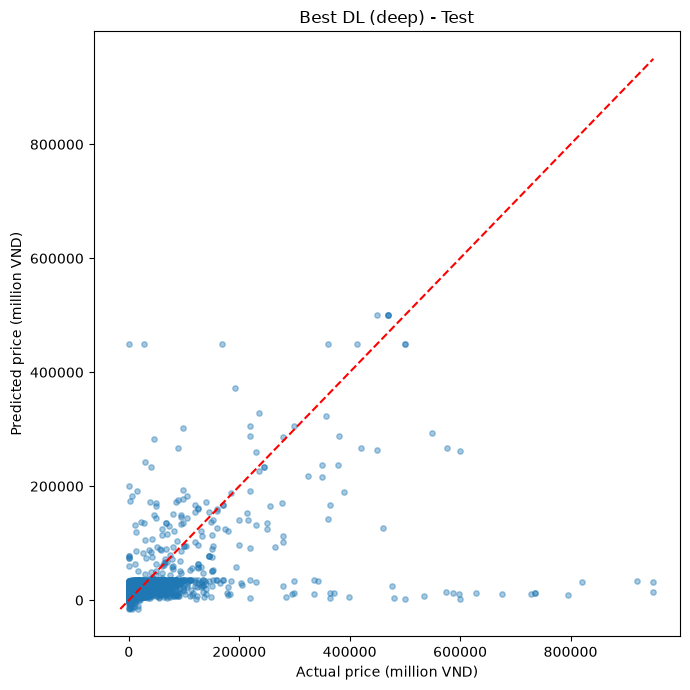

In [24]:
y_pred_best_dl = eval_dl(best_model, X_test_nn)

plt.figure(figsize=(7, 7))
plt.scatter(y_test, y_pred_best_dl, alpha=0.4, s=15)

lims = [
    min(y_test.min(), y_pred_best_dl.min()),
    max(y_test.max(), y_pred_best_dl.max())
]

plt.plot(lims, lims, "r--", lw=1.5)
plt.xlabel("Actual price (million VND)")
plt.ylabel("Predicted price (million VND)")
plt.title(f"Best DL ({best_name}) - Test")
plt.tight_layout()
plt.show()


## 18. Residual analysis

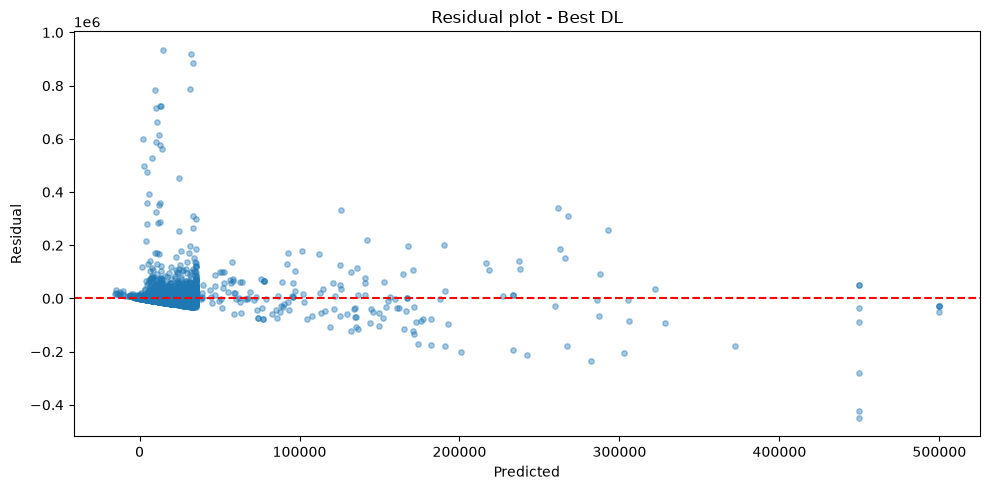

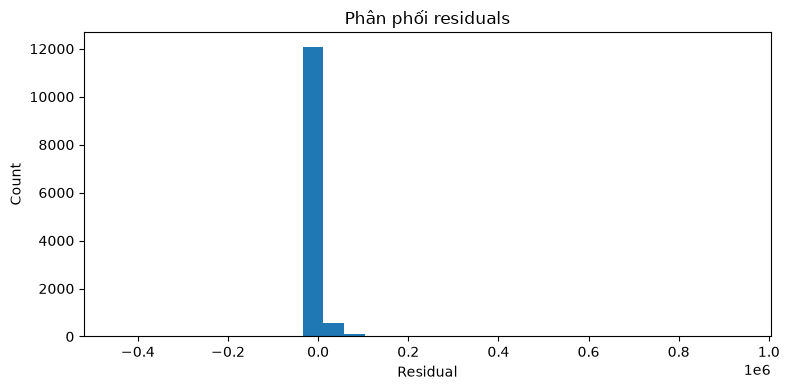

In [25]:
residuals = y_test - y_pred_best_dl

plt.figure(figsize=(10, 5))
plt.scatter(y_pred_best_dl, residuals, alpha=0.4, s=15)
plt.axhline(0, color="red", linestyle="--")
plt.xlabel("Predicted")
plt.ylabel("Residual")
plt.title("Residual plot - Best DL")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 4))
plt.hist(residuals, bins=30)
plt.title("Phân phối residuals")
plt.xlabel("Residual")
plt.ylabel("Count")
plt.tight_layout()
plt.show()


## 19. Ảnh hưởng của learning rate / optimizer / batch size / depth

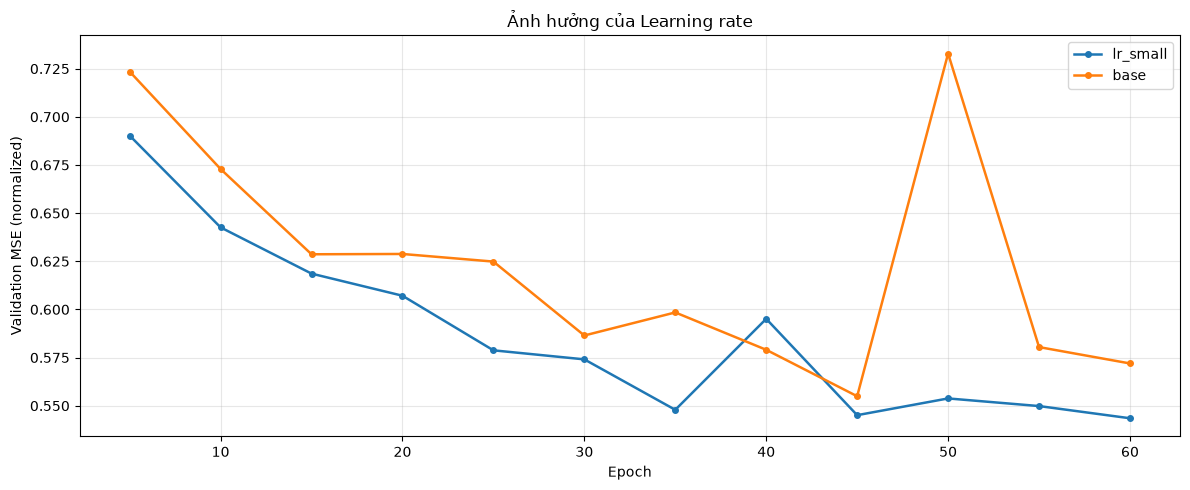

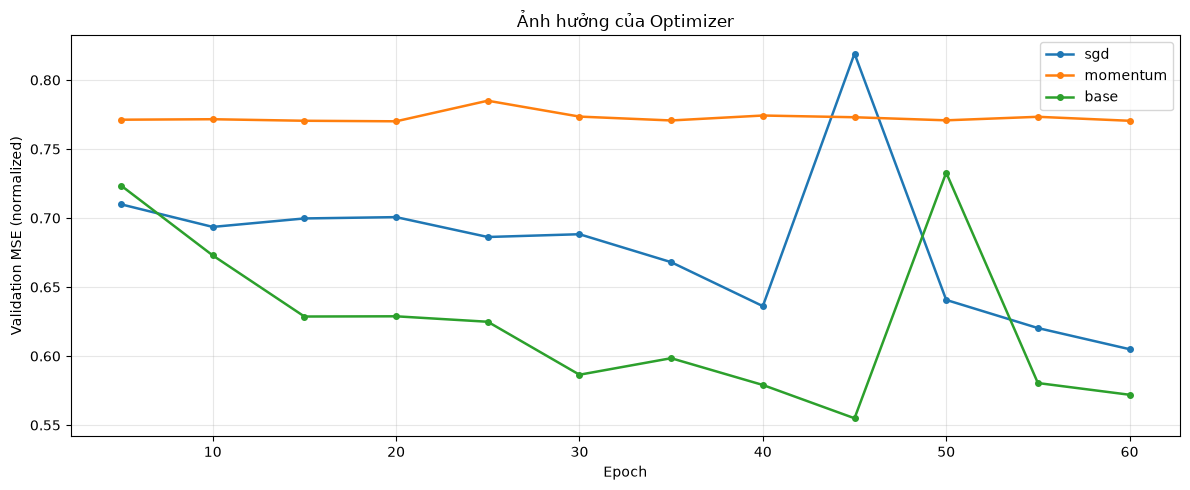

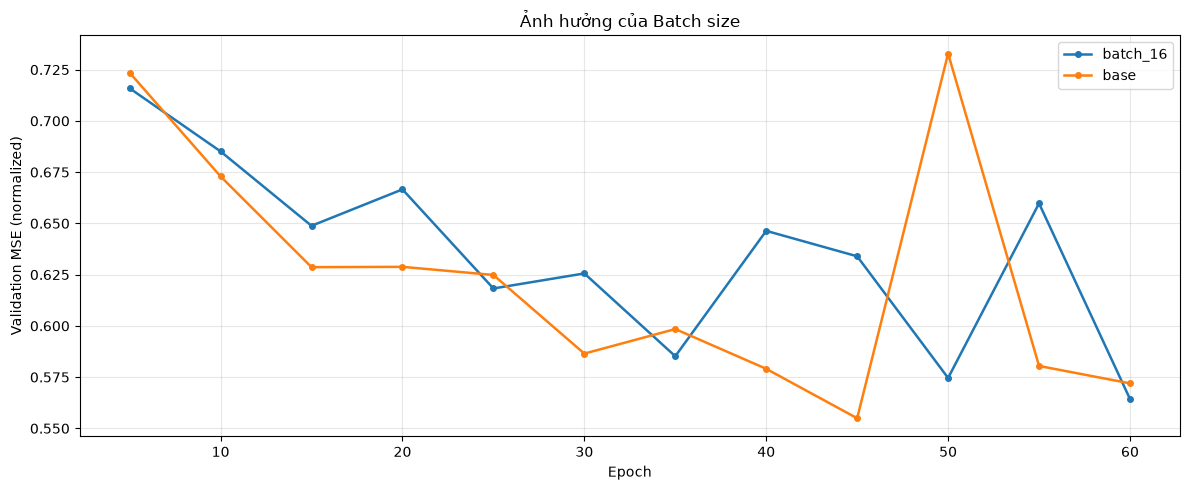

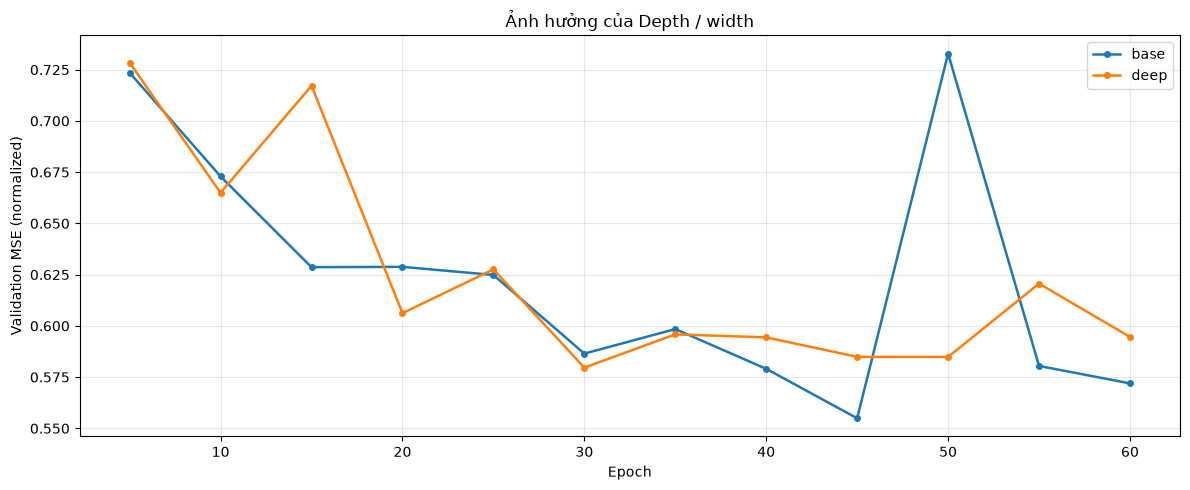

In [33]:
groups = {
    "Learning rate": ["lr_small", "base", "lr_large"],
    "Optimizer":     ["sgd", "momentum", "base"],
    "Batch size":    ["batch_16", "base", "batch_128"],
    "Depth / width": ["shallow", "base", "deep"]
}

EVAL_EVERY = 5   # phải khớp với lúc train

for title, names in groups.items():
    plt.figure(figsize=(12, 5))

    for name in names:
        if name not in dl_histories:
            continue

        h = dl_histories[name]
        val_loss = h["val_loss"]

        # Trường hợp 1: history mới có val_epoch -> dùng trực tiếp
        if "val_epoch" in h and len(h["val_epoch"]) == len(val_loss):
            x = h["val_epoch"]
            y = val_loss
        else:
            # Trường hợp 2: history cũ, có NaN xen kẽ -> lọc NaN
            arr = np.array(val_loss, dtype=float)
            mask = ~np.isnan(arr)
            # epoch tương ứng: vị trí i (0-based) -> epoch i+1
            # nếu bạn append NaN ở các epoch không eval, thì epoch eval là i+1
            x = np.arange(1, len(arr) + 1)[mask]
            y = arr[mask]

        plt.plot(x, y, marker="o", markersize=4,
                 linewidth=1.8, label=name)

    plt.xlabel("Epoch")
    plt.ylabel("Validation MSE (normalized)")
    plt.title(f"Ảnh hưởng của {title}")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

## 20. K-Fold Cross Validation cho DL (optional)

In [27]:
def kfold_cv_dl(
    X,
    y,
    k=5,
    epochs=100,
    batch_size=32,
    hidden_dims=(64, 32, 16, 8),
    lr=0.01,
    optimizer="adam"
):
    kf = KFold(n_splits=k, shuffle=True, random_state=42)
    scores = []

    for fold, (tr_idx, va_idx) in enumerate(kf.split(X)):
        X_tr, X_va = X[tr_idx], X[va_idx]
        y_tr, y_va = y[tr_idx], y[va_idx]

        ym = y_tr.mean()
        ys = y_tr.std() + 1e-8

        y_tr_n = (y_tr - ym) / ys
        y_va_n = (y_va - ym) / ys

        model = MLPRegressor(
            input_dim=X.shape[1],
            hidden_dims=hidden_dims,
            lr=lr,
            optimizer=optimizer,
            seed=42 + fold
        )

        train_mlp(
            model,
            X_tr,
            y_tr_n,
            X_va,
            y_va_n,
            epochs=epochs,
            batch_size=batch_size,
            verbose=False
        )

        pred = model.predict(X_va) * ys + ym

        scores.append({
            "fold": fold + 1,
            "RMSE": np.sqrt(mean_squared_error(y_va, pred)),
            "R2": r2_score(y_va, pred)
        })

    return pd.DataFrame(scores)

cv_df = kfold_cv_dl(
    X_train_nn,
    y_train,
    k=5,
    epochs=100,
    batch_size=32
)

display(cv_df)
print("CV mean:")
display(cv_df[["RMSE", "R2"]].mean().to_frame("mean").T)


,fold,RMSE,R2
0,1,35514.352978,-0.001240
1,2,30605.483687,0.195629
2,3,40686.039479,-0.001739
3,4,33149.011249,0.132162
4,5,26372.261400,0.197948


CV mean:


,RMSE,R2
mean,33265.429759,0.104552


## 21. Save model bằng NumPy

In [28]:
save_dict = {}

for i, (w, b) in enumerate(zip(best_model.W, best_model.b)):
    save_dict[f"W{i}"] = w
    save_dict[f"b{i}"] = b

save_dict["y_mean"] = np.array(y_mean)
save_dict["y_std"] = np.array(y_std)
save_dict["hidden_dims"] = np.array(best_model.hidden_dims)

np.savez("best_mlp_house.npz", **save_dict)

print("Đã lưu: best_mlp_house.npz")
loaded = np.load("best_mlp_house.npz")
print("Keys:", list(loaded.keys()))


Đã lưu: best_mlp_house.npz
Keys: ['W0', 'b0', 'W1', 'b1', 'W2', 'b2', 'W3', 'b3', 'W4', 'b4', 'y_mean', 'y_std', 'hidden_dims']


## 22. Final leaderboard

Bảng này là kết quả cuối cùng để đưa vào báo cáo Assignment 02.


In [29]:
final = pd.concat([
    ml_test[["Model", "RMSE", "MAE", "R2"]].assign(Type="ML"),
    dl_df_test[["Model", "RMSE", "MAE", "R2"]].assign(Type="DL")
], ignore_index=True)

final = final[["Type", "Model", "RMSE", "MAE", "R2"]].sort_values("RMSE")

print("========== FINAL LEADERBOARD ==========")
display(final)

best_overall = final.iloc[0]

print("\nBest overall:")
print("Type :", best_overall["Type"])
print("Model:", best_overall["Model"])
print("RMSE :", round(best_overall["RMSE"], 3))
print("MAE  :", round(best_overall["MAE"], 3))
print("R2   :", round(best_overall["R2"], 3))


========== FINAL LEADERBOARD ==========


,Type,Model,RMSE,MAE,R2
4,DL,deep,32648.594018,8812.401680,0.271786
2,ML,RandomForest,33080.200732,7349.411941,0.252405
5,DL,lr_small,33092.558503,8194.972123,0.251846
8,DL,batch_16,33215.580964,9080.948989,0.246273
3,DL,base,33481.737133,9516.155026,0.234146
6,DL,sgd,34670.084015,9699.930913,0.178817
1,ML,Ridge,36765.890279,10740.538086,0.076535
0,ML,LinearRegression,38286.388600,11141.777344,-0.001427
7,DL,momentum,38310.353278,11499.187487,-0.002681



Best overall:
Type : DL
Model: deep
RMSE : 32648.594
MAE  : 8812.402
R2   : 0.272
